/tmp/ipykernel_2046/2491583473.py:18: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  missing = [pip_name for module_name, pip_name in required_packages.items() if pkgutil.find_loader(module_name) is None]


INTERNSHIP PROJECT: STOCK MARKET TREND PREDICTION USING MACHINE LEARNING
Domain      : Finance
Dataset     : Historical stock prices from Yahoo Finance
Target      : Predict whether next-day closing price will go UP or DOWN
Algorithm   : Random Forest Classifier



[*********************100%***********************]  1 of 1 completed



First 5 rows of dataset:
        Date      Close       High        Low       Open     Volume
0 2018-01-02  40.267078  40.276431  39.565806  39.776190  102223600
1 2018-01-03  40.260067  40.802386  40.196955  40.330195  118071600
2 2018-01-04  40.447075  40.549929  40.225006  40.332532   89738400
3 2018-01-05  40.907574  40.994063  40.451747  40.542912   94640000
4 2018-01-08  40.755623  41.050156  40.657442  40.755623   82271200

Dataset shape: (1761, 6)

Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Creating technical indicators...

Summary statistics:
                                mean              std                  min  \
Date             2021-07-25 14:12:30              NaN  2018-02-20 00:00:00   
Close                     123.187248        58.464526            33.737007   
High                      124.409023         58.92475             34.57456   
Low                       121.826658        57.912546            33.691

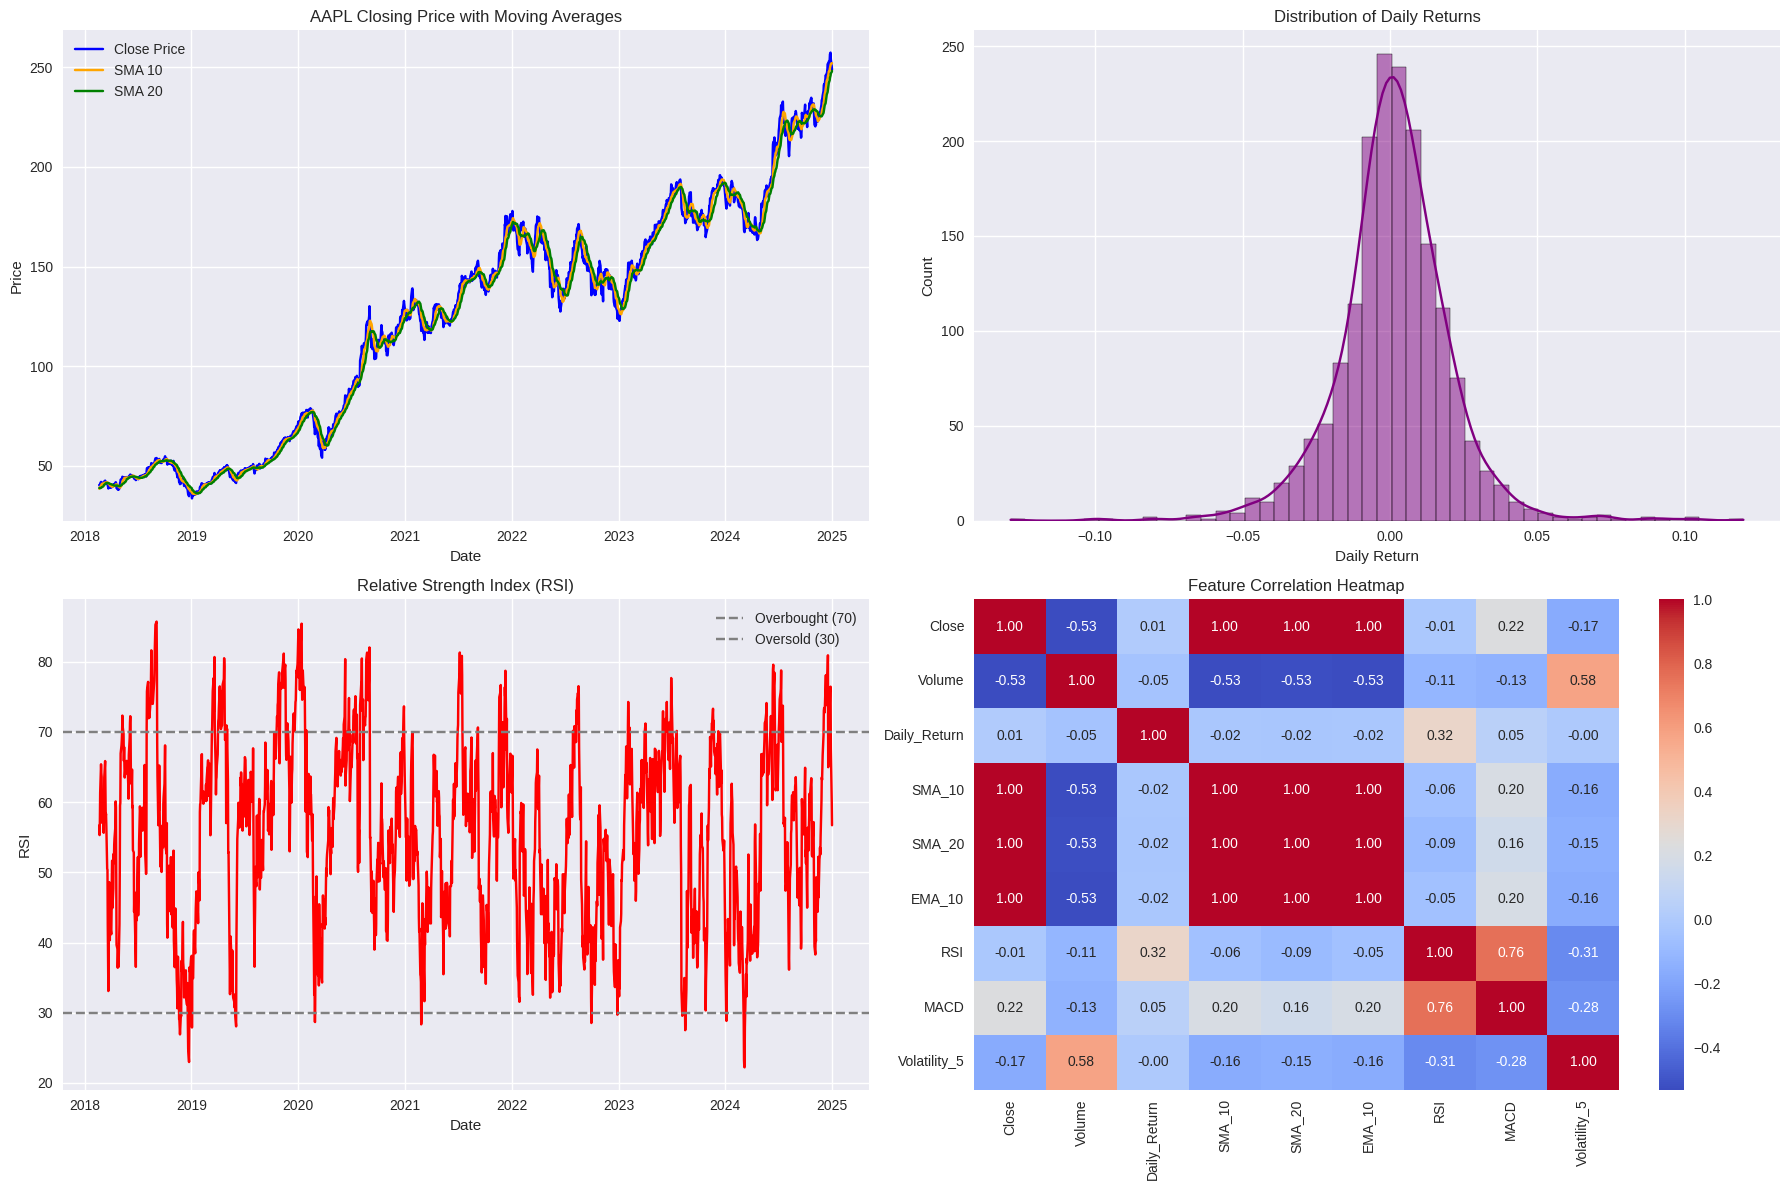


Training samples: 1382
Testing samples : 346

MODEL EVALUATION
Accuracy: 0.4538

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.97      0.60       149
           1       0.72      0.07      0.12       197

    accuracy                           0.45       346
   macro avg       0.58      0.52      0.36       346
weighted avg       0.60      0.45      0.33       346



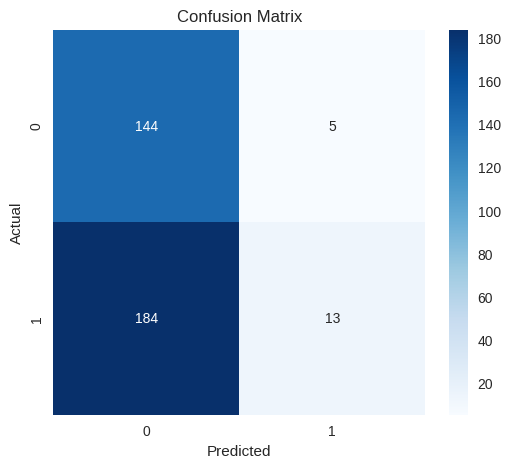

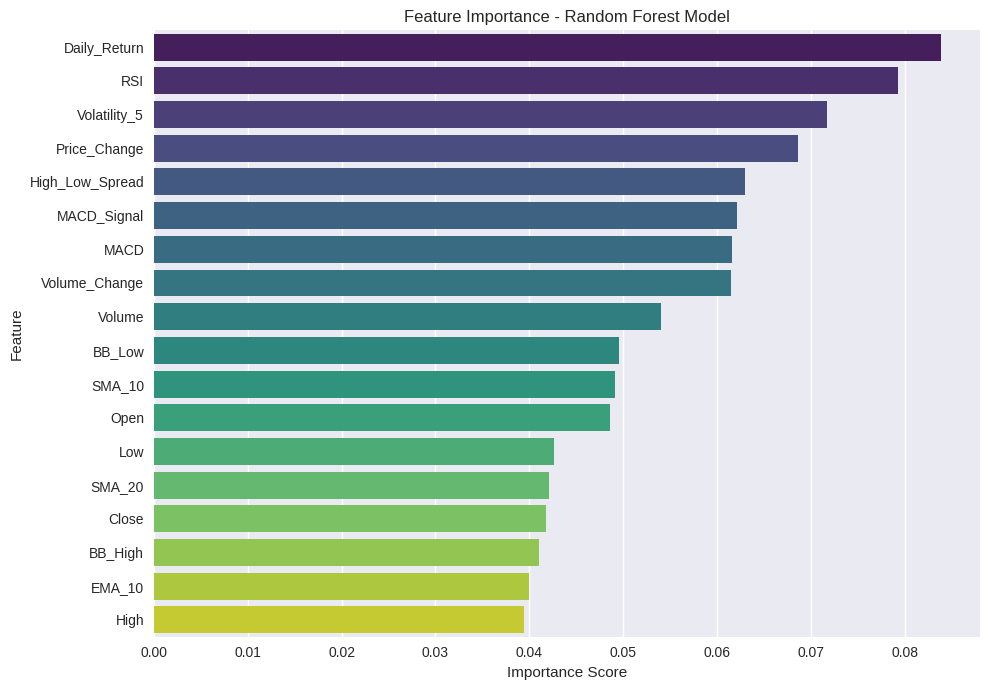


Top 10 Important Features:
            Feature  Importance
5      Daily_Return    0.083821
9               RSI    0.079309
14     Volatility_5    0.071688
15     Price_Change    0.068647
16  High_Low_Spread    0.063009
11      MACD_Signal    0.062140
10             MACD    0.061548
17    Volume_Change    0.061475
4            Volume    0.054010
13           BB_Low    0.049577

Sample predictions:
     Actual_Label Predicted_Label
1415           UP            DOWN
1416           UP              UP
1417           UP            DOWN
1418           UP            DOWN
1419         DOWN            DOWN
1420           UP            DOWN
1421           UP            DOWN
1422           UP            DOWN
1423           UP            DOWN
1424           UP            DOWN

PROJECT CONCLUSION
1. The dataset contains real historical stock market data for AAPL.
2. Technical indicators such as RSI, MACD, moving averages, and volatility were used as predictive features.
3. The Random Forest model a

In [1]:
# Real-World Data Science Project for Internship (Finance Domain)
# Google Colab Ready - Single Code Cell Script

# =========================
# 1. Install dependencies
# =========================
import sys
import subprocess
import pkgutil

required_packages = {
    'yfinance': 'yfinance',
    'ta': 'ta',
    'sklearn': 'scikit-learn',
    'seaborn': 'seaborn'
}

missing = [pip_name for module_name, pip_name in required_packages.items() if pkgutil.find_loader(module_name) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)

# =========================
# 2. Import libraries
# =========================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator, EMAIndicator
from ta.volatility import BollingerBands

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

plt.style.use('seaborn-v0_8')
sns.set_palette('deep')
plt.rcParams['figure.max_open_warning'] = 0

# =========================
# 3. Project title
# =========================
print('='*80)
print('INTERNSHIP PROJECT: STOCK MARKET TREND PREDICTION USING MACHINE LEARNING')
print('='*80)
print('Domain      : Finance')
print('Dataset     : Historical stock prices from Yahoo Finance')
print('Target      : Predict whether next-day closing price will go UP or DOWN')
print('Algorithm   : Random Forest Classifier')
print('='*80)

# =========================
# 4. Load real-world dataset
# =========================
stock_symbol = 'AAPL'   # You can change this to MSFT, TSLA, AMZN, GOOGL, etc.
start_date = '2018-01-01'
end_date = '2025-01-01'

print(f"\nDownloading data for {stock_symbol} from Yahoo Finance...")
df = yf.download(stock_symbol, start=start_date, end=end_date, auto_adjust=True)

# Handle multi-index columns if returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

df = df.reset_index()
print('\nFirst 5 rows of dataset:')
print(df.head())

print('\nDataset shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())

# =========================
# 5. Feature engineering
# =========================
print('\nCreating technical indicators...')

df['Daily_Return'] = df['Close'].pct_change()
df['SMA_10'] = SMAIndicator(close=df['Close'], window=10).sma_indicator()
df['SMA_20'] = SMAIndicator(close=df['Close'], window=20).sma_indicator()
df['EMA_10'] = EMAIndicator(close=df['Close'], window=10).ema_indicator()
df['RSI'] = RSIIndicator(close=df['Close'], window=14).rsi()

macd = MACD(close=df['Close'])
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()

bb = BollingerBands(close=df['Close'], window=20, window_dev=2)
df['BB_High'] = bb.bollinger_hband()
df['BB_Low'] = bb.bollinger_lband()

df['Volatility_5'] = df['Daily_Return'].rolling(5).std()
df['Price_Change'] = df['Close'] - df['Open']
df['High_Low_Spread'] = df['High'] - df['Low']
df['Volume_Change'] = df['Volume'].pct_change()

# Target variable: 1 if next day's close is higher than today's close, else 0
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop null rows created by rolling indicators
model_df = df.dropna().copy()

# =========================
# 6. Exploratory Data Analysis
# =========================
print('\nSummary statistics:')
print(model_df.describe().T[['mean', 'std', 'min', 'max']])

# =========================
# 7. Visualizations
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Closing price over time
axes[0, 0].plot(model_df['Date'], model_df['Close'], label='Close Price', color='blue')
axes[0, 0].plot(model_df['Date'], model_df['SMA_10'], label='SMA 10', color='orange')
axes[0, 0].plot(model_df['Date'], model_df['SMA_20'], label='SMA 20', color='green')
axes[0, 0].set_title(f'{stock_symbol} Closing Price with Moving Averages')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')
axes[0, 0].legend()

# Plot 2: Daily return distribution
sns.histplot(model_df['Daily_Return'], bins=50, kde=True, ax=axes[0, 1], color='purple')
axes[0, 1].set_title('Distribution of Daily Returns')
axes[0, 1].set_xlabel('Daily Return')

# Plot 3: RSI indicator
axes[1, 0].plot(model_df['Date'], model_df['RSI'], color='red')
axes[1, 0].axhline(70, linestyle='--', color='gray', label='Overbought (70)')
axes[1, 0].axhline(30, linestyle='--', color='gray', label='Oversold (30)')
axes[1, 0].set_title('Relative Strength Index (RSI)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('RSI')
axes[1, 0].legend()

# Plot 4: Correlation heatmap
feature_cols_for_heatmap = ['Close', 'Volume', 'Daily_Return', 'SMA_10', 'SMA_20', 'EMA_10', 'RSI', 'MACD', 'Volatility_5']
correlation = model_df[feature_cols_for_heatmap].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()
plt.close()

# =========================
# 8. Prepare data for ML
# =========================
features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return',
    'SMA_10', 'SMA_20', 'EMA_10', 'RSI', 'MACD', 'MACD_Signal',
    'BB_High', 'BB_Low', 'Volatility_5', 'Price_Change',
    'High_Low_Spread', 'Volume_Change'
]

X = model_df[features]
y = model_df['Target']

# Time-based split (important for stock data)
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f'\nTraining samples: {len(X_train)}')
print(f'Testing samples : {len(X_test)}')

# =========================
# 9. Train model
# =========================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# =========================
# 10. Evaluate model
# =========================
accuracy = accuracy_score(y_test, y_pred)
print('\n' + '='*80)
print('MODEL EVALUATION')
print('='*80)
print(f'Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.close()

# =========================
# 11. Feature importance
# =========================
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
plt.close()

print('\nTop 10 Important Features:')
print(importance_df.head(10))

# =========================
# 12. Prediction sample output
# =========================
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Actual_Label'] = results['Actual'].map({1: 'UP', 0: 'DOWN'})
results['Predicted_Label'] = results['Predicted'].map({1: 'UP', 0: 'DOWN'})

print('\nSample predictions:')
print(results[['Actual_Label', 'Predicted_Label']].head(10))

# =========================
# 13. Business / internship conclusion
# =========================
up_days = model_df['Target'].mean() * 100

print('\n' + '='*80)
print('PROJECT CONCLUSION')
print('='*80)
print(f'1. The dataset contains real historical stock market data for {stock_symbol}.')
print('2. Technical indicators such as RSI, MACD, moving averages, and volatility were used as predictive features.')
print(f'3. The Random Forest model achieved an accuracy of {accuracy:.2%} in predicting next-day stock movement.')
print('4. This project demonstrates a complete data science workflow: data collection, cleaning, feature engineering, visualization, model building, and evaluation.')
print('5. For internship presentation, you can explain that this project helps investors or analysts understand short-term stock trends using machine learning.')
print(f'6. In this dataset, approximately {up_days:.2f}% of days showed an upward next-day movement.')
print('7. Future improvements: use more stocks, add sentiment analysis from news, try XGBoost/LSTM, and optimize hyperparameters.')
print('='*80)

# =========================
# 14. Optional: next-day prediction
# =========================
latest_features = X.tail(1)
next_day_prediction = model.predict(latest_features)[0]
next_day_prob = model.predict_proba(latest_features)[0]

print('\nLatest model prediction for next trading day:')
print('Prediction:', 'UP' if next_day_prediction == 1 else 'DOWN')
print(f'Probability of DOWN: {next_day_prob[0]:.2%}')
print(f'Probability of UP  : {next_day_prob[1]:.2%}')

print('\nProject completed successfully. This code is ready to run in Google Colab as a single cell.')
